# Code-Übung 2: Finite-Differenzen-Methode
Themen dieser Übung sind:

* Vorwärtsdifferenzen
* Zentraldifferenzen
* 3-Punkt-Zentraldifferenzen
* Konvergenzanalyse

In [7]:
import sys
import numpy as np
from scipy.linalg import solve

# import helper functions, depending on whether we are running in Google Colab or not

IN_COLAB = "google.colab" in sys.modules # check if we are running in Google Colab (if module exists, we are)

if IN_COLAB:
    # clone the repository to access the helper functions (the version on the main branch)
    !git clone https://github.com/CPShub/LectureNSM.git 
    from LectureNSM.ex1_time_integration.helper_functions import plot_force, plot_deflection, plot_convergence
    %rm -rf LectureNSM  # delete the folder after importing, to enable re-importing if we run the cell again

else:
    from helper_functions import plot_force, plot_deflection, plot_convergence


## 1D-Finite-Differenzen: Der Kragarm 
Gegeben sein ein Kragarm mit einer allgemeinen Linienlast $q(x)$ und der eingeprägten Kraft $F$ am freien Ende. Der Balken habe einen kreisförmigen Querschnitt mit dem Durchmesser $d(x)$. Außerdem sei der E-Modul $E = 1 \cdot 10^5 \frac{N}{m^2}$ gegeben. Gesucht sind der Querkraftverlauf $Q(x)$, der Biegemomentenverlauf $M(x)$ und die Durchbiegung $w(x)$.

<img src="./graphics/Kragarm.png" style="width: 50%;">

Um das Problem mit der FDM lösen zu können, muss der betrachtete Balken zunächst diskretisiert und freigeschnitten werden.

<img src="./graphics/Diskretisierung.png" style="width: 50%;">

### Modellparameter

In [8]:
N = 11                                          # number of points
L = 1                                           # length of the cantilever in m
q = 0                                           # line load in N/m
F = 1                                           # load at the tip of the cantilever in N
E = 1e5                                         # Youngs modulus in N/m^2

delta_x = L/(N-1)                               # Step size in m
x_axis = np.linspace(0, L, N)                   # x-positions to be evaluated in m
d = 0.1*np.ones((1,N))                          # Beam diameter at every x-position to be evaluated in m    
# d(7) = 0.05;
# d = 0.15-x_axis*0.1;                          # Variable diameter of the beam in m

I = np.array([np.pi/64*d_val**4 for d_val in d])    # Moment of inertia at every x-position to be evaluated in m^4

### Querkraft (Vorwärtsdifferenzen)
Für den Zusammenhang zwischen der Linienlast $q(x)$ und der Querkraft $Q(x)$ gilt folgender Ausdruck
$$
\frac{dQ(x)}{dx} = - q(x)
$$
Dieser wird mittels Vorwärtsdifferenzen diskretisiert:
$$
\frac{Q_{i+1} + Q_i}{\Delta x} = - q_i
$$
Umstellen und Überführen in die kompakte Koeffizientenschreibweise ergibt:
$$
Q_i =  Q_{i+1} - q_i \cdot \Delta x \\
\alpha ^i _P \cdot Q_i = \alpha ^i _E \cdot Q_{i+1} + f_i
$$
Im Allgemeinen müsssen die Koeffizienzen $\alpha ^i _P, \alpha ^i _E, f_i$ für jeden Punkt $i$ neu berechnet und in den gezeigten Ausdruck eingesetzt werden. Im gezeigten Beispiel gilt jedoch $\alpha ^i _P = \alpha ^i _E = 1$. Der letzte betrachtete Punkt ist als Sonderfall zu betrachten, da der "darauffolgende" Punkt $Q_{i+1}$ außerhalb des Gitters liegt. Dadurch fällt eine Gleichung weg, die jedoch durch die Randbedingung ausgeglichen wird. Diese ist gegeben als die eingeprägte Kraft $F$. Es gilt:
$$
Q(x=L) = F
$$
In der diskretisierten Schreibweise gilt an der Stelle $x=L$:
$$
\alpha ^{N} _P \cdot Q_{N} = F
$$
Iterieren über alle Punkte $i$ führt auf das LGS $\boldsymbol{K \cdot Q} = \boldsymbol{f}$, wobei jede Zeile die Berechnung an einem Punkt repräsentiert und die Randbedingung in der letzten Zeile integriert ist:
$$
\begin{bmatrix}
    \alpha ^1 _P & -\alpha ^1 _E & 0 & 0 & ... & 0\\
    0 & \alpha ^2 _P & -\alpha ^2 _E &  0 & ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    0 & ...  & ... & 0 & 0 & \alpha ^N _P\\
\end{bmatrix}
\cdot
\begin{bmatrix}
Q_1 \\
Q_2 \\
\vdots \\
Q_N
\end{bmatrix}
=
\begin{bmatrix}
f_1\\
f_2\\
\vdots\\
F
\end{bmatrix}
$$

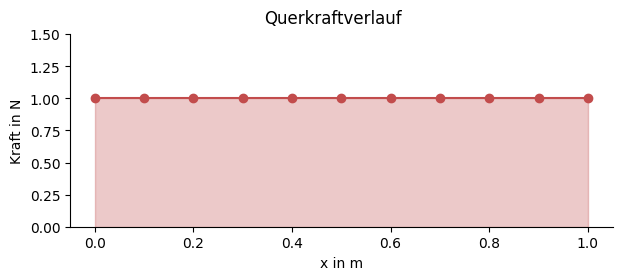

In [ ]:
a_P = lambda idx: 1
a_E = lambda idx: 1
f_i = lambda idx: -q * delta_x

# Assembling the stiffness matrix
K = np.zeros((N, N))
for idx in range(N):
    K[idx][idx] = a_P(idx)          # Major diagonal
    
    if idx+1 < N:
        K[idx][idx+1] = - a_E(idx)  # Minor diagonal

# Calculating the load vector
f = np.array([f_i(idx) for idx in range(N)])

# Adding the boundary condition
f[-1] = F

# Solving the system of equations
Q = solve(K, f)

plot_force(x_axis, Q, "Querkraftverlauf", "Kraft in N")
print(K)

### Biegemoment (Zentraldifferenzen)
Für den Zusammenhang zwischen der Querkraft $Q(x)$ und dem Biegemoment $M(x)$ gilt folgender Ausdruck
$$
\frac{dM(x)}{dx} = Q(x)
$$
Dieser wird mittels Zentraldifferenzen diskretisiert:
$$
\frac{M_{i+1} - M_{i-1}}{2 \Delta x} = Q_i
$$
Umstellen und Überführen in die kompakte Koeffizientenschreibweise ergibt:
$$
0 =  M_{i-1} - M_{i+1} + 2 \Delta x \cdot Q_i\\
0 =  \alpha ^i _W \cdot M_{i-1} + \alpha ^i _E \cdot M_{i+1} + f_i
$$
Die Punkte $i = 1$ und $i = N$ müssen gesondert betrachtet werden, da hier jeweils der Wert $M_{i-1}$ bzw. $M_{i+1}$ außerhalb des Gitters liegt. Hierdurch fallen zwei Gleichungen (Zeilen in der Matrix) weg, sodass das LGS zunächst unterbestimmt ist. Die erste Bedinung kann jedoch wie zuvor wieder mittels einer Randbedingung hinzugefügt werden.
$$
M(x=L) = 0\\
\alpha ^{N} _P \cdot M_{N} = 0
$$
Die zweite Gleichung kann "aufgefüllt" werden, indem der letzte Punkt mittels Rückwärtsdifferenzen betrachtet wird.
$$
\frac{M_N-M_{N-1}}{\Delta x} = Q_N\\
M_N = M_{N-1} + \Delta x \cdot Q_N
$$
Unter Einbezug der Randbedingung und der Rückwärtsdifferenzen als zusätzliche Gleichungen, entsteht folgendes Gleichungssystem:
$$
\begin{bmatrix}
    0 & 0 & 0 & 0 & ... & \alpha ^N _P\\
    \alpha ^2 _W & 0 & -\alpha ^2 _E & 0 & ... & 0\\
    0 & \alpha ^3 _W &0 & -\alpha ^3 _E &  ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    0 & ...  & ... & 0 & \alpha ^N _W & \alpha ^N _P\\
\end{bmatrix}
\cdot
\begin{bmatrix}
M_1 \\
M_2 \\
M_3\\
\vdots \\
M_N
\end{bmatrix}
=
\begin{bmatrix}
0\\
f_2\\
f_3\\
\vdots\\
\Delta x \cdot Q_N
\end{bmatrix}
$$

In [ ]:
a_W = lambda idx: 1
a_E = lambda idx: - 1
f_i = lambda idx: 2 * delta_x * Q[idx]

# Assembling the stiffness matrix
K = np.zeros((N, N))
for idx in range(1, N-1):           # Note: First and last rows are omitted
    K[idx][idx+1] = - a_E(idx)      # First minor diagonal
    
    if idx > 0:
        K[idx][idx-1] = - a_W(idx)  # Second minor diagonal

# Calculating the load vector
f = np.array([f_i(idx) for idx in range(N)])

# Boundary condition at the right end
K[0, -1] = 1
f[0] = 0

# Backward difference at the right end
K[-1][-1] = 1
K[-1][-2] = -1
f[-1] = delta_x * Q[N-1]

# Solving the system of equations
M = solve(K, f)

plot_force(x_axis, M, "Momentenverlauf", "Biegemoment in Nm")

### Biegelinie (3-Punkt-Zentraldifferenz)
In dieser Aufgabe wird direkt die zweite Ableitungs diskretisiert. Für den Zusammenhang zwischen der Durchbiegung $w(x)$ und dem Biegemoment $M(x)$ gilt folgender Ausdruck
$$
\frac{d^2 w(x)}{dx^2} \cdot EI(x) = -M(x)
$$
Die Verschiebung $w(x)$ wird mittels der 3-Punkt-Zentraldifferenz diskretisiert:
$$
\frac{w_{i-1} - 2 w_i + w_{i+1}}{\Delta x^2} \cdot EI(x) = -M(x)
$$
Umstellen und Überführen in die kompakte Koeffizientenschreibweise ergibt:
$$
-2 w_i =  - w _{i-1}-w_{i+1} + \frac{-M(x) \cdot \Delta x^2}{E I(x)}\\
\alpha ^i _P \cdot w_i=  \alpha ^i _E \cdot w_{i+1} + \alpha ^i _W \cdot w_{i-1} + f_i
$$
Die Punkte $i = 1$ und $i = N$ müssen gesondert betrachtet werden, da hier jeweils der Wert $w_{i-1}$ bzw. $w_{i+1}$ außerhalb des Gitters liegt. Hierdurch fallen zwei Gleichungen weg, sodass das LGS zunächst unterbestimmt ist. Im hier betrachteten Fall können jedoch beide Gleichungen mit Randbedingungen "aufgefüllt" werden. Zunächst die Dirichlet-Randbedingung:
$$
w(x=0) = 0\\
\alpha ^{1} _P \cdot w_{1} = 0 \\
$$
Die Neumann-Randbedingung kann durch Approximieren der Ableitung am Rand durch die 3-Punkt-Vorwärtsdifferenz berücksichtigt werden:
$$
\frac{dw(x=0)}{dx} = 0\\
\frac{-3 w_1 + 4w_2 -w_3}{2 \Delta x} = 0\\
-3 w_1 = -4 w_2 + w_3\\
a_P^1 \cdot w_1 = a_E^1 \cdot w_2 + a_{EE}^1 \cdot w_3 
$$
Unter Einbezug der Randbedingung entsteht folgendes Gleichungssystem:
$$
\begin{bmatrix}
    \alpha ^1 _P & -\alpha ^1 _E & -\alpha ^1 _{EE} & 0 & ... & 0\\
    \alpha ^2 _W & 0 & -\alpha ^2 _E & 0 & ... & 0\\
    0 & \alpha ^3 _W &0 & -\alpha ^3 _E &  ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    \alpha ^1 _P & ...  & ... & 0 & 0 & 0\\
\end{bmatrix}
\cdot
\begin{bmatrix}
w_1 \\
w_2 \\
w_3\\
\vdots \\
w_N
\end{bmatrix}
=
\begin{bmatrix}
0\\
f_2\\
f_3\\
\vdots\\
0
\end{bmatrix}
$$

In [ ]:
a_W = lambda idx: -1
a_E = lambda idx: - 1
a_P = lambda idx: -2
f_i = lambda idx: -M[idx]*delta_x**2/(E*I[0, idx])

# Assembling the stiffness matrix
K = np.zeros((N, N))
for idx in range(1, N-1):           # Note: First and last rows are omitted
    K[idx][idx] = a_P(idx)          # Major diagonal
    K[idx][idx+1] = - a_E(idx)      # First minor diagonal
    
    if idx > 0:
        K[idx][idx-1] = - a_W(idx)  # Second minor diagonal

# Calculating the load vector
f = np.array([f_i(idx) for idx in range(N)])

# Boundary condition w=0 at the left end
K[0, 0] = 1
f[0] = 0

# Boundary condition dw/dx=0 at the left end
K[-1][0] = -3
K[-1][1] = 4
K[-1][2] = -1
f[-1] = 0

# Solving the system of equations
w = solve(K, f)

# Analytical solution
w_analytical = np.array([F*x**2/(6*E*I[0, idx])*(3*L-x) for idx, x in enumerate(x_axis)])

plot_deflection(x_axis, w, w_analytical, "Biegelinie", "Verschiebung in m")

## Konvergenzanalyse
Nun soll die Konvergenzordnung der gezeigten Verfahren betrachtet werden. Hierzu wird die Differentialgleichung 
$$
u(x) = \frac{df(x)}{dx}
$$
mit
$$
f(x) = sin(x)
$$
gewählt. Die exakte Lösung ist als
$$
u_{exakt}(x) = cos(x)
$$
bekannt. Die Konvergenzordnung kann basierend auf drei numerischen Lösungen $\Phi$ mit unterschiedlicher Schrittweite $h$ geschätzt werden:
$$
p = log_2 \frac{\Phi _ {2h} - \Phi _{4h}}{\Phi _{h} - \Phi _{2h}}
$$


In [ ]:
# For the actual calculation
step_sizes = [5e-5, 1e-4, 2e-4]
phi_fds = np.zeros((3, 1))
phi_cds = np.zeros((3, 1))

f = lambda x: np.sin(x)
x0 = np.pi / 4

for idx, h in enumerate(step_sizes):
    phi_fds[idx] = (f(x0 + h) - f(x0)) / h
    phi_cds[idx] = (f(x0 + h) - f(x0 - h)) / (2 * h)

p = lambda phi_h, phi_2h, phi_4h: np.log2((phi_2h-phi_4h)/(phi_h-phi_2h))
p_fds = p(phi_fds[0], phi_fds[1], phi_fds[2])
p_cds = p(phi_cds[0], phi_cds[1], phi_cds[2])

print(f"Die Vorwärtsdifferenz hat die geschätzte Konvergenzordnung p = {p_fds}.")
print(f"Die Zentraldifferenz hat die geschätzte Konvergenzordnung p = {p_cds}.")

# Error as function of step size
step_sizes = np.logspace(-6, -1, 50)
err_fds = np.zeros((50, 1))
err_cds = np.zeros((50, 1))

u_exact = lambda x: np.cos(x)

for idx, h in enumerate(step_sizes):
    err_fds[idx] = abs(u_exact(x0) - (f(x0 + h) - f(x0)) / h)
    err_cds[idx] = abs(u_exact(x0) - (f(x0 + h) - f(x0 - h)) / (2 * h))

plot_convergence(step_sizes, err_fds, err_cds, "Vorwärtsdifferenz", "Zentraldifferenz")
